<a href="https://colab.research.google.com/github/pattichis/AdvancedPython/blob/main/UMAP_supervised_dimension_reduction_and_metric_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Refer to UMAP documentation page on [UMAP for Supervised Dimension Reduction and Metric Learning](https://umap-learn.readthedocs.io/en/latest/supervised.html)

In [ ]:
!pip install umap-learn


In [ ]:
import numpy as np
# from mnist.loader import MNIST
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style='white', context='poster')

In [ ]:
import math
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn.functional as F


# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

# Create data loaders.
train_dataloader = DataLoader(training_data)
test_dataloader = DataLoader(test_data)

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


# Equivalent to train, train_labels
train = training_data.data
train_labels = training_data.targets

# Equivalent to test, test_labels
test = test_data.data
test_labels = test_data.targets

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 232kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.31MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.1MB/s]


In [ ]:
data = np.array(np.vstack([train, test]), dtype=np.float64) / 255.0
target = np.hstack([train_labels, test_labels])

In [ ]:
import umap

data_reshaped = data.reshape(data.shape[0], -1)
embedding = umap.UMAP(n_neighbors=5).fit_transform(data_reshaped)

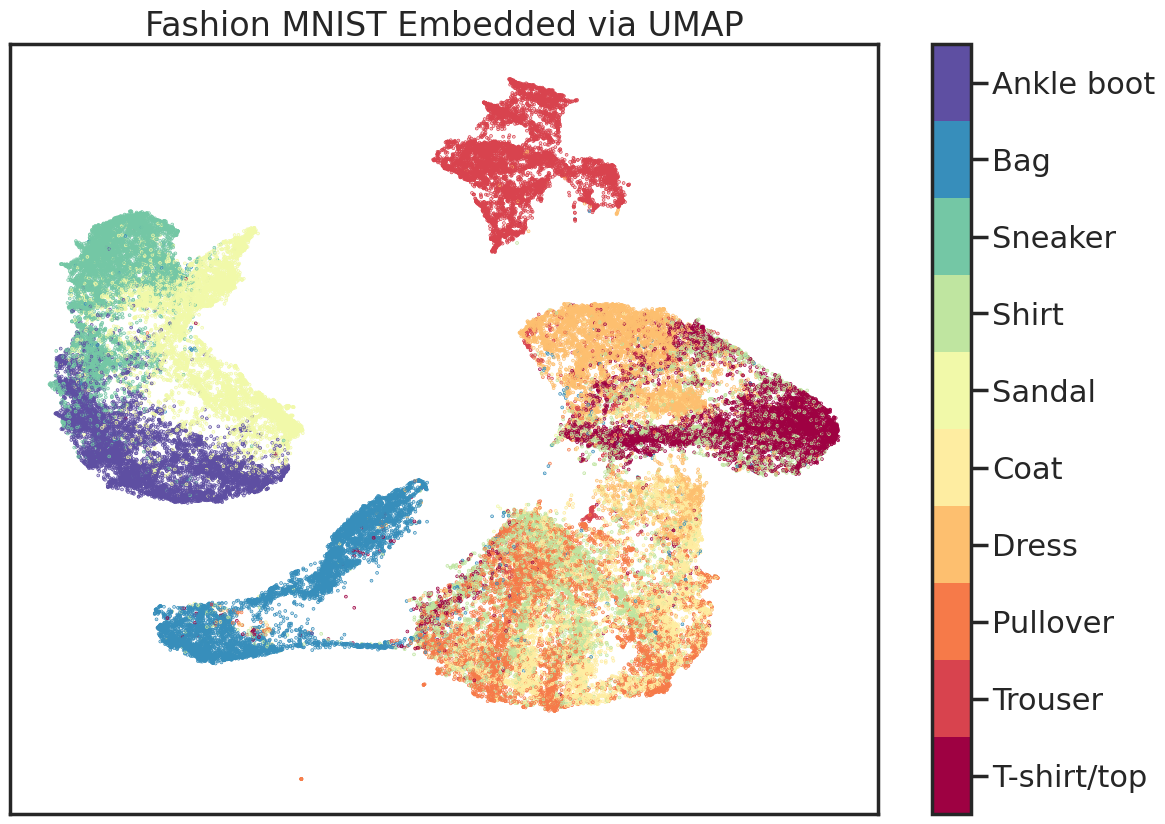

In [ ]:
fig, ax = plt.subplots(1, figsize=(14, 10))
plt.scatter(*embedding.T, s=0.3, c=target, cmap='Spectral', alpha=1.0)
plt.setp(ax, xticks=[], yticks=[])
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(classes)
plt.title('Fashion MNIST Embedded via UMAP');

In [ ]:
embedding = umap.UMAP().fit_transform(data_reshaped, y=target)

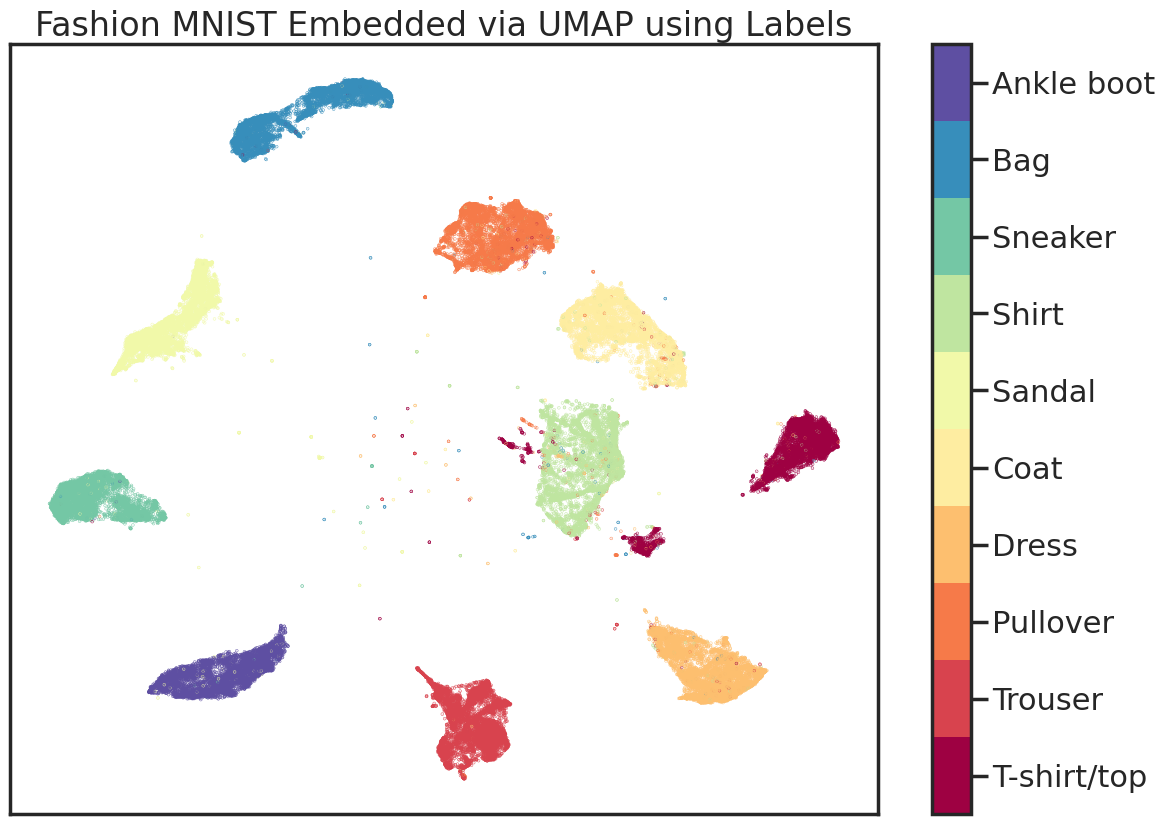

In [ ]:
fig, ax = plt.subplots(1, figsize=(14, 10))
plt.scatter(*embedding.T, s=0.1, c=target, cmap='Spectral', alpha=1.0)
plt.setp(ax, xticks=[], yticks=[])
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(classes)
plt.title('Fashion MNIST Embedded via UMAP using Labels');

In [ ]:
masked_target = target.copy().astype(np.int8)
masked_target[np.random.choice(70000, size=10000, replace=False)] = -1

In [ ]:
fitter = umap.UMAP().fit(data_reshaped, y=masked_target)
embedding = fitter.embedding_

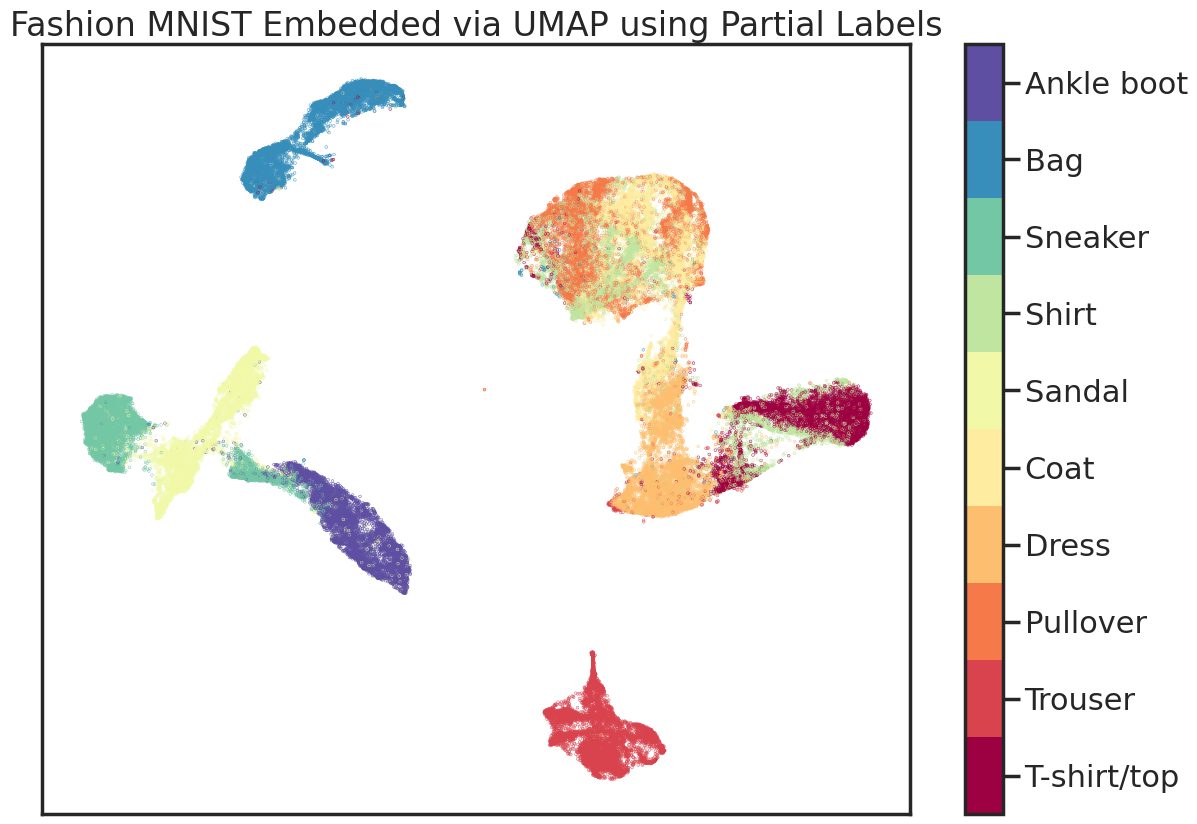

In [ ]:
fig, ax = plt.subplots(1, figsize=(14, 10))
plt.scatter(*embedding.T, s=0.1, c=target, cmap='Spectral', alpha=1.0)
plt.setp(ax, xticks=[], yticks=[])
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(classes)
plt.title('Fashion MNIST Embedded via UMAP using Partial Labels');

In [ ]:
train_data = np.array(train)
test_data = np.array(test)

In [ ]:
mapper = umap.UMAP(n_neighbors=10).fit(train_data.reshape(train_data.shape[0], -1), np.array(train_labels))

In [ ]:
test_embedding = mapper.transform(test_data.reshape(test_data.shape[0], -1))

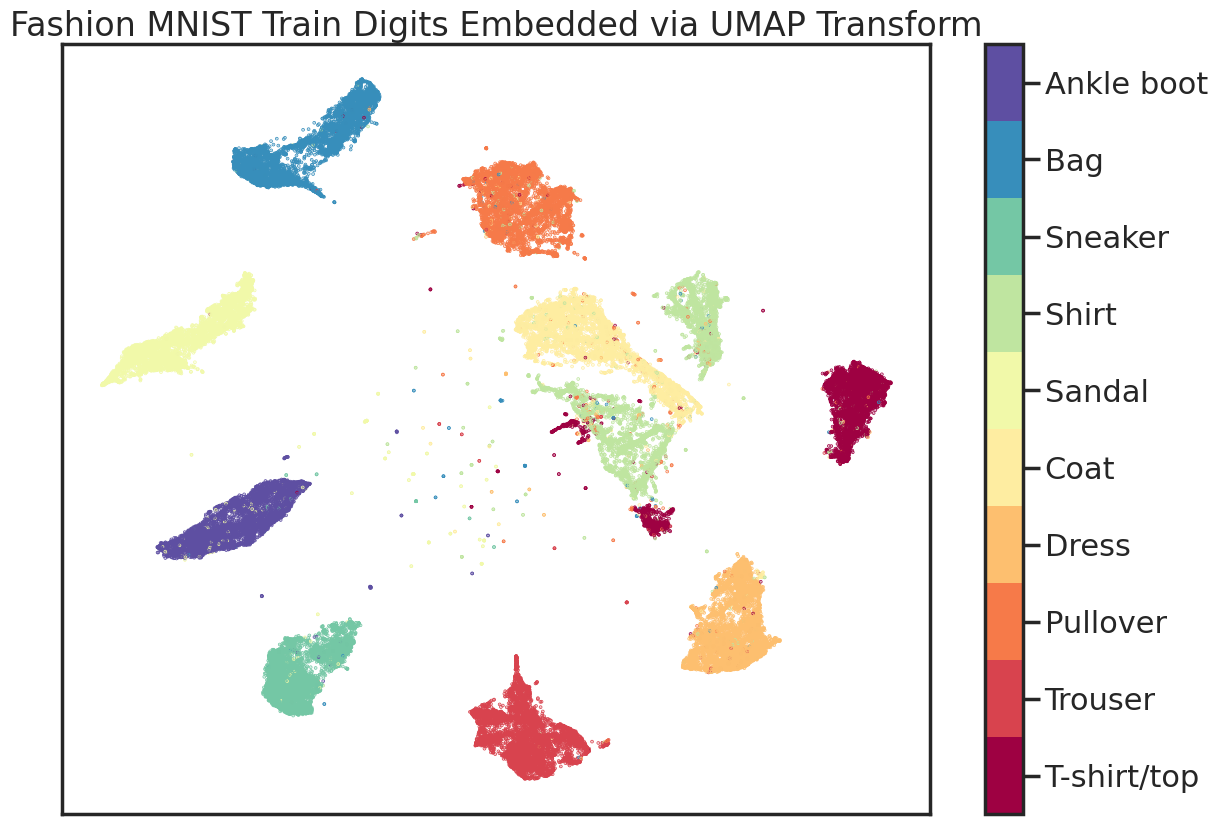

In [ ]:
fig, ax = plt.subplots(1, figsize=(14, 10))
plt.scatter(*mapper.embedding_.T, s=0.3, c=np.array(train_labels), cmap='Spectral', alpha=1.0)
plt.setp(ax, xticks=[], yticks=[])
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(classes)
plt.title('Fashion MNIST Train Digits Embedded via UMAP Transform');

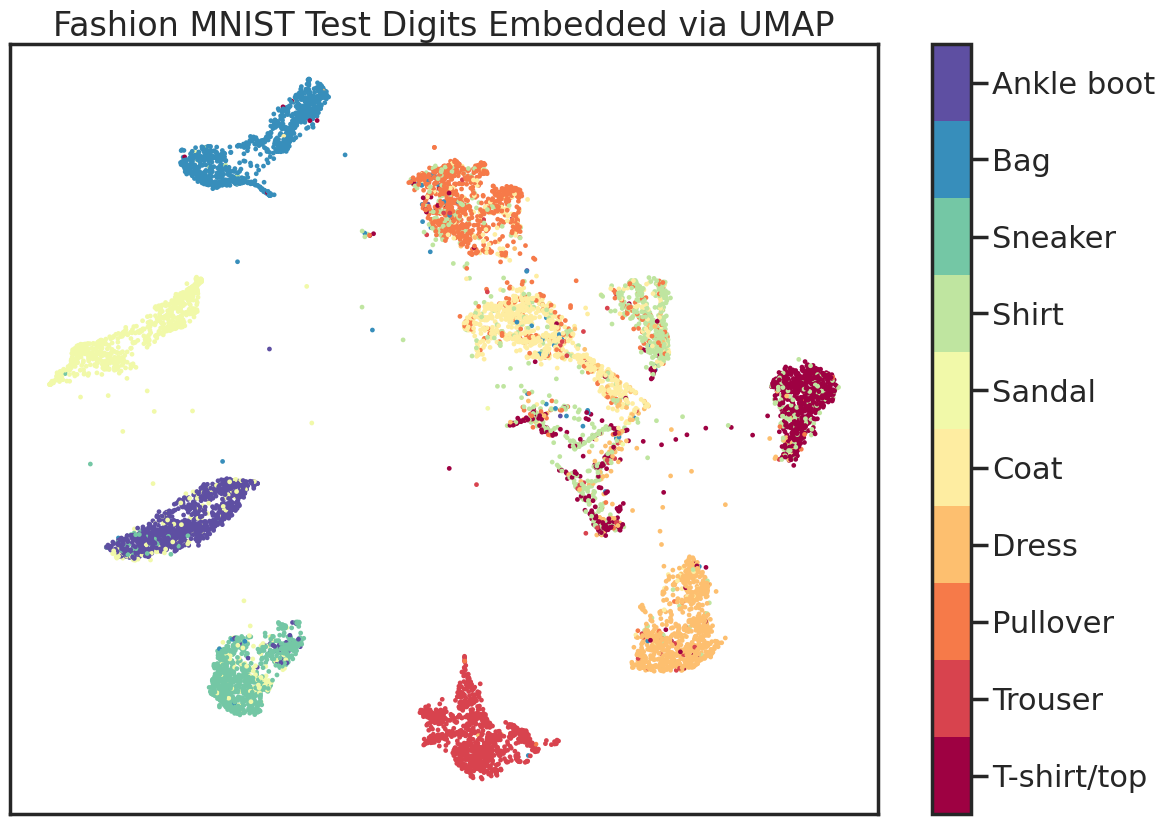

In [ ]:
fig, ax = plt.subplots(1, figsize=(14, 10))
plt.scatter(*test_embedding.T, s=2, c=np.array(test_labels), cmap='Spectral', alpha=1.0)
plt.setp(ax, xticks=[], yticks=[])
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(classes)
plt.title('Fashion MNIST Test Digits Embedded via UMAP');

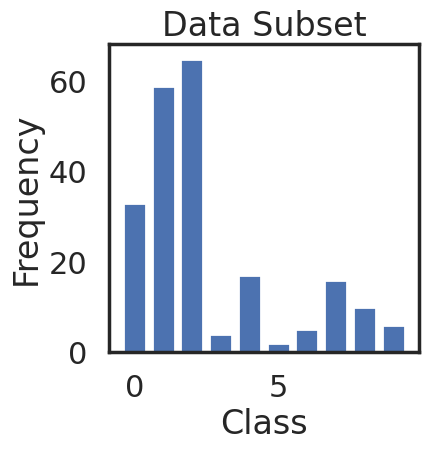

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import umap
import os
import math
import requests

if not os.path.isfile("Galaxy10.h5"):
    url = "http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5"
    r = requests.get(url, allow_redirects=True)
    open("Galaxy10.h5", "wb").write(r.content)

# To get the images and labels from file
with h5py.File("Galaxy10.h5", "r") as F:
    images = np.array(F["images"])
    labels = np.array(F["ans"])

X_train = np.empty([math.floor(len(labels) / 100), 14283], dtype=np.float64)
y_train = np.empty([math.floor(len(labels) / 100)], dtype=np.float64)
X_test = X_train
y_test = y_train
# Get a subset of the data
for i in range(math.floor(len(labels) / 100)):
    X_train[i, :] = np.array(np.ndarray.flatten(images[i, :, :, :]), dtype=np.float64)
    y_train[i] = labels[i]
    X_test[i, :] = np.array(
        np.ndarray.flatten(images[i + math.floor(len(labels) / 100), :, :, :]),
        dtype=np.float64,
    )
    y_test[i] = labels[i + math.floor(len(labels) / 100)]

# Plot distribution
classes, frequency = np.unique(y_train, return_counts=True)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.bar(classes, frequency)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Data Subset")
plt.savefig("galaxy10_subset.svg")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


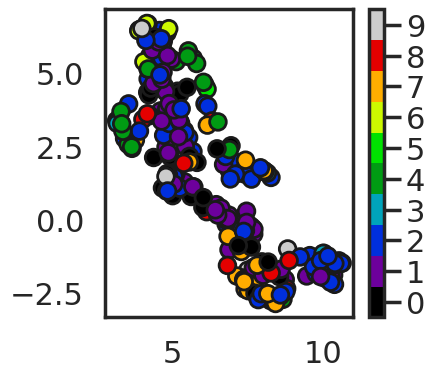

In [ ]:
reducer = umap.UMAP(
    n_components=2, n_neighbors=5, random_state=42, transform_seed=42, verbose=False
)
reducer.fit(X_train)

galaxy10_umap = reducer.transform(X_train)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.scatter(
    galaxy10_umap[:, 0],
    galaxy10_umap[:, 1],
    c=y_train,
    cmap=plt.cm.nipy_spectral,
    edgecolor="k",
    label=y_train,
)
plt.colorbar(boundaries=np.arange(11) - 0.5).set_ticks(np.arange(10))
plt.savefig("galaxy10_2D_umap.svg")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


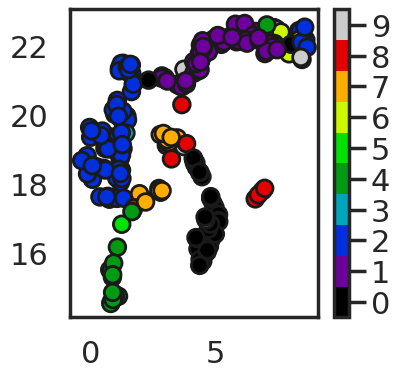

In [ ]:
reducer = umap.UMAP(
    n_components=2, n_neighbors=15, random_state=42, transform_seed=42, verbose=False
)
reducer.fit(X_train, y_train)

galaxy10_umap_supervised = reducer.transform(X_train)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.scatter(
    galaxy10_umap_supervised[:, 0],
    galaxy10_umap_supervised[:, 1],
    c=y_train,
    cmap=plt.cm.nipy_spectral,
    edgecolor="k",
    label=y_train,
)
plt.colorbar(boundaries=np.arange(11) - 0.5).set_ticks(np.arange(10))
plt.savefig("galaxy10_2D_umap_supervised.svg")

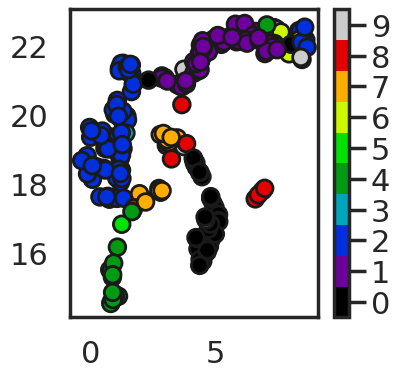

In [ ]:
galaxy10_umap_supervised_prediction = reducer.transform(X_test)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.scatter(
    galaxy10_umap_supervised_prediction[:, 0],
    galaxy10_umap_supervised_prediction[:, 1],
    c=y_test,
    cmap=plt.cm.nipy_spectral,
    edgecolor="k",
    label=y_test,
)
plt.colorbar(boundaries=np.arange(11) - 0.5).set_ticks(np.arange(10))
plt.savefig("galaxy10_2D_umap_supervised_prediction.svg")